In [27]:
import pandas as pd

titanic_df = pd.read_csv('Updated_Titanic_Data.csv')

In [28]:
titanic_df.head()

,PassengerId,initials,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,new_initials,PStatus
0,1.0,Mr,0,"Braund, Mr. Owen Harris",male,22.0,1.0,0.0,A/5 21171,7.2500,False,S,Mr,3
1,2.0,Mrs,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1.0,0.0,PC 17599,71.2833,True,C,Mrs,1
2,3.0,Miss,1,"Heikkinen, Miss. Laina",female,26.0,0.0,0.0,STON/O2. 3101282,7.9250,False,S,Miss,3
3,4.0,Mrs,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1.0,0.0,113803,53.1000,True,S,Mrs,1
4,5.0,Mr,0,"Allen, Mr. William Henry",male,35.0,0.0,0.0,373450,8.0500,False,S,Mr,3


In [29]:
titanic_df.describe()

,PassengerId,Survived,Age,SibSp,Parch,Fare,PStatus
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,446.000000,0.382452,29.347773,0.524184,0.382452,32.096681,2.311586
std,256.998173,0.486260,13.202558,1.103705,0.806761,49.697504,0.834700
min,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,1.000000
25%,224.000000,0.000000,21.500000,0.000000,0.000000,7.895800,2.000000
50%,446.000000,0.000000,30.000000,0.000000,0.000000,14.454200,3.000000
75%,668.000000,1.000000,35.000000,1.000000,0.000000,31.000000,3.000000
max,891.000000,1.000000,80.000000,8.000000,6.000000,512.329200,3.000000


<Axes: xlabel='Age', ylabel='Fare'>

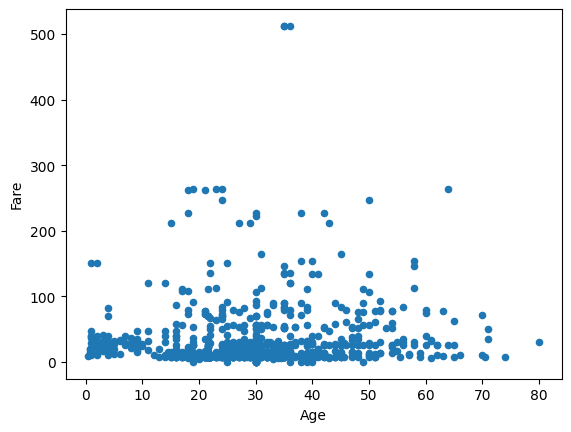

In [30]:
titanic_df.plot(kind = 'scatter', x = 'Age', y = 'Fare')

<Axes: xlabel='Age', ylabel='Survived'>

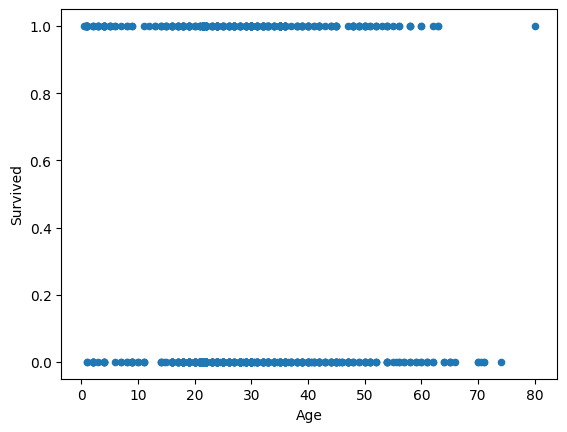

In [31]:
titanic_df.plot(kind = 'scatter', x = 'Age', y = 'Survived')

# Chi-Square
A chi-square (\(\chi ^{2}\)) test is a statistical method used to analyze categorical data to determine if observed frequencies differ significantly from expected frequencies. It is commonly used to test for independence between two categorical variables or to assess the "goodness of fit" of a model.

Key Types of Chi-Square TestsChi-Square Test of Independence: Evaluates if two categorical variables are related, comparing observed sample data to a scenario where they are independent.Chi-Square Goodness of Fit Test: Determines if the frequency distribution of a single categorical variable matches an expected theoretical distribution.


In [32]:
# !pip install scipy

In [33]:
from scipy.stats import chi2_contingency

In [34]:
contengency_table = pd.crosstab(titanic_df.PStatus, titanic_df.Survived)
contengency_table

Survived,0,1
PStatus,,
1,80,134
2,97,87
3,372,119


In [35]:
chi2_score, pvalue, dof , expected_freq = chi2_contingency(contengency_table)

print(f"Chi-Square test score = {round(chi2_score, 3)}")
print(f"p-value = {round(pvalue, 5)}")

Chi-Square test score = 100.98
p-value = 0.0


#Interpret Results
 - If the p-value is less than a certain significance level (e.g., 0.05), then we reject the null hypothesis, which is commonly denoted by α. Thus, it means that category variables highly correlate with each other.
 - When a p-value is above α, it implies that we cannot reject the null hypothesis; hence, there is insufficient evidence for establishing the relationship between these variables.

No significant evidence supports the claim that men prefer vanilla or women prefer chocolate (p>0.05).

In [36]:
contengency_table = pd.crosstab(titanic_df.Embarked, titanic_df.SibSp)
contengency_table

SibSp,0.0,1.0,2.0,3.0,4.0,5.0,8.0
Embarked,,,,,,,
C,109,53,6,0,0,0,0
Q,59,11,3,0,4,0,0
S,438,145,19,16,14,5,7


In [ ]:
chi2_score, pvalue, dof, expected_freq = chi2_contingency(contengency_table)

print(f"Chi-Square test score = {round(chi2_score, 3)}")
print(f"p-value = {round(pvalue, 5)}")

Chi-Square test score = 27.009
p-value = 0.0077


In [38]:
expected_freq

array([[1.14519685e+02, 3.94960630e+01, 5.29133858e+00, 3.02362205e+00,
        3.40157480e+00, 9.44881890e-01, 1.32283465e+00],
       [5.24881890e+01, 1.81023622e+01, 2.42519685e+00, 1.38582677e+00,
        1.55905512e+00, 4.33070866e-01, 6.06299213e-01],
       [4.38992126e+02, 1.51401575e+02, 2.02834646e+01, 1.15905512e+01,
        1.30393701e+01, 3.62204724e+00, 5.07086614e+00]])